
# Transforms v2: End-to-end object detection/segmentation example

<div class="alert alert-info"><h4>Note</h4><p>Try on [Colab](https://colab.research.google.com/github/pytorch/vision/blob/gh-pages/main/_generated_ipynb_notebooks/plot_transforms_e2e.ipynb)
    or `go to the end <sphx_glr_download_auto_examples_transforms_plot_transforms_e2e.py>` to download the full example code.</p></div>

Object detection and segmentation tasks are natively supported:
``torchvision.transforms.v2`` enables jointly transforming images, videos,
bounding boxes, and masks.

This example showcases an end-to-end instance segmentation training case using
Torchvision utils from ``torchvision.datasets``, ``torchvision.models`` and
``torchvision.transforms.v2``. Everything covered here can be applied similarly
to object detection or semantic segmentation tasks.


<b> Before we start the training part it important to download and import the necessary file which is the helpers and the own dataset that has instance segmenetation from roboflow.

In [1]:
!pip install helpers > /dev/null
!pip install roboflow > /dev/null

In [2]:
# for the dataset we try to use the image that is capable in detecting cans
# the data is imported from roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="pGRthGiIPMMgCIST4ApK")
project = rf.workspace("new-workspace-crr3c").project("r2p2")
version = project.version(2)
dataset = version.download("coco")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to R2P2-2 in coco:: 100%|██████████| 2753/2753 [01:03<00:00, 43.20it/s] 


In [3]:
import pathlib

import torch
import torch.utils.data

from torchvision import models, datasets, tv_tensors
from torchvision.transforms import v2

torch.manual_seed(0)

# This loads fake data for illustration purposes of this example. In practice, you'll have
# to replace this with the proper data.
# If you're trying to run that on Colab, you can download the assets and the
# helpers from https://github.com/pytorch/vision/tree/main/gallery/
ROOT = pathlib.Path("/content/R2P2-2")
IMAGES_PATH = str(ROOT / "train")
ANNOTATIONS_PATH = str(ROOT / "train/_annotations.coco.json")
# from helpers import plot

> We modified the path

## Dataset preparation

We start off by loading the :class:`~torchvision.datasets.CocoDetection` dataset to have a look at what it currently
returns.



> The dataset was taken from roboflow

> https://universe.roboflow.com/new-workspace-crr3c/r2p2

In [4]:
dataset = datasets.CocoDetection(IMAGES_PATH, ANNOTATIONS_PATH)

sample = dataset[0]
img, target = sample
print(f"{type(img) = }\n{type(target) = }\n{type(target[0]) = }\n{target[0].keys() = }")

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
type(img) = <class 'PIL.Image.Image'>
type(target) = <class 'list'>
type(target[0]) = <class 'dict'>
target[0].keys() = dict_keys(['id', 'image_id', 'category_id', 'bbox', 'area', 'segmentation', 'iscrowd'])


Torchvision datasets preserve the data structure and types as it was intended
by the datasets authors. So by default, the output structure may not always be
compatible with the models or the transforms.

To overcome that, we can use the
:func:`~torchvision.datasets.wrap_dataset_for_transforms_v2` function. For
:class:`~torchvision.datasets.CocoDetection`, this changes the target
structure to a single dictionary of lists:



In [5]:
dataset_transform = datasets.wrap_dataset_for_transforms_v2(dataset, target_keys=("boxes", "labels", "masks"))

In [6]:
sample = dataset_transform[1]
img, target = sample
print(f"{type(img) = }\n{type(target) = }\n{target.keys() = }")

type(img) = <class 'PIL.Image.Image'>
type(target) = <class 'dict'>
target.keys() = dict_keys(['boxes', 'masks', 'labels'])


In [7]:
print(f"{type(target['boxes']) = }\n{type(target['labels']) = }\n{type(target['masks']) = }")

type(target['boxes']) = <class 'torchvision.tv_tensors._bounding_boxes.BoundingBoxes'>
type(target['labels']) = <class 'torch.Tensor'>
type(target['masks']) = <class 'torchvision.tv_tensors._mask.Mask'>


We used the ``target_keys`` parameter to specify the kind of output we're
interested in. Our dataset now returns a target which is dict where the values
are `TVTensors <what_are_tv_tensors>` (all are :class:`torch.Tensor`
subclasses). We're dropped all unncessary keys from the previous output, but
if you need any of the original keys e.g. "image_id", you can still ask for
it.

<div class="alert alert-info"><h4>Note</h4><p>If you just want to do detection, you don't need and shouldn't pass
    "masks" in ``target_keys``: if masks are present in the sample, they will
    be transformed, slowing down your transformations unnecessarily.</p></div>

As baseline, let's have a look at a sample without transformations:



In [9]:
from helpers import plot

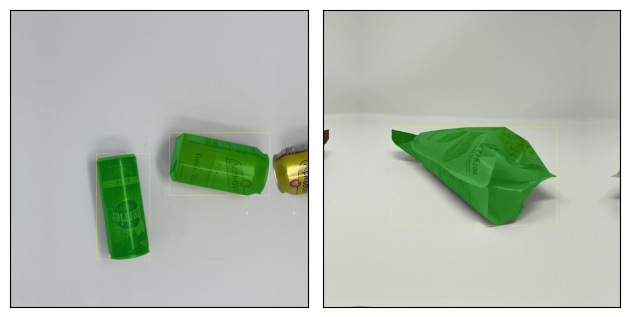

In [10]:
plot([dataset_transform[0], dataset_transform[1]])

## Transforms

Let's now define our pre-processing transforms. All the transforms know how
to handle images, bounding boxes and masks when relevant.

Transforms are typically passed as the ``transforms`` parameter of the
dataset so that they can leverage multi-processing from the
:class:`torch.utils.data.DataLoader`.



In [11]:
# since we are using before we start the training part
# we can create different kinds of augmentation, since we forget to do it
# in the roboflow before we import it into this collab.

transforms = v2.Compose(
    [
        v2.ToImage(),
        v2.RandomPhotometricDistort(p=1),
        v2.RandomZoomOut(fill={tv_tensors.Image: (123, 117, 104), "others": 0}),
        v2.RandomIoUCrop(),
        v2.RandomHorizontalFlip(p=1),
        v2.SanitizeBoundingBoxes(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

dataset = datasets.CocoDetection(IMAGES_PATH, ANNOTATIONS_PATH, transforms=transforms)
dataset = datasets.wrap_dataset_for_transforms_v2(dataset, target_keys=["boxes", "labels", "masks"])

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


A few things are worth noting here:

- We're converting the PIL image into a
  :class:`~torchvision.transforms.v2.Image` object. This isn't strictly
  necessary, but relying on Tensors (here: a Tensor subclass) will
  `generally be faster <transforms_perf>`.
- We are calling :class:`~torchvision.transforms.v2.SanitizeBoundingBoxes` to
  make sure we remove degenerate bounding boxes, as well as their
  corresponding labels and masks.
  :class:`~torchvision.transforms.v2.SanitizeBoundingBoxes` should be placed
  at least once at the end of a detection pipeline; it is particularly
  critical if :class:`~torchvision.transforms.v2.RandomIoUCrop` was used.

Let's look how the sample looks like with our augmentation pipeline in place:



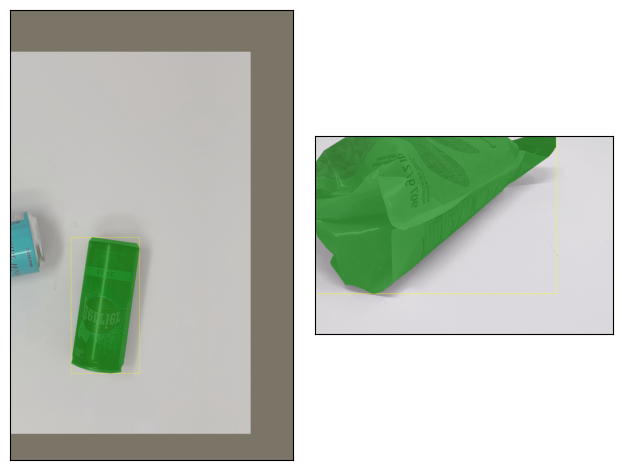

In [12]:
# visuallize the dataset
plot([dataset[0], dataset[1]])

We can see that the color of the images were distorted, zoomed in or out, and flipped.
The bounding boxes and the masks were transformed accordingly. And without any further ado, we can start training.

## Data loading and training loop

Below we're using Mask-RCNN which is an instance segmentation model, but
everything we've covered in this tutorial also applies to object detection and
semantic segmentation tasks.



In [15]:
# Basically when we try to run the whole training set
# we got run out of GPU since we are only using free access in colab

import torch
# we only limit the data from 1k images
# And run it for 5 epochs only since the original only runs for 1 epoch
indices = torch.arange(200).tolist()
dataset_subset = torch.utils.data.Subset(dataset, indices)

data_loader = torch.utils.data.DataLoader(
    dataset_subset,
    batch_size=2,
    # We need a custom collation function here, since the object detection
    # models expect a sequence of images and target dictionaries.
    collate_fn=lambda batch: tuple(zip(*batch)),
    shuffle=True
)
# Furthermore we also use the pretrained weights of the maskrcnn_resnet 50 instead of no weights from the original code
# This is
model = models.get_model("maskrcnn_resnet50_fpn_v2", weights="COCO_V1", weights_backbone="ResNet50_Weights.IMAGENET1K_V1").train()

# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

print(f"Training on {device}...")

counter = 0

for imgs, targets in data_loader:
    imgs = [img.to(device) for img in imgs]
    targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

    loss_dict = model(imgs, targets)

    # Print losses of every loss dictionary
    losses = sum(loss for loss in loss_dict.values())
    print(f"Batch Loss: {losses.item():.4f}")

    # print the final loss in every epochs
    for name, loss_val in loss_dict.items():
        print(f"{name:<20}{loss_val:.3f}")
    if counter == 5:
        break

    counter += 1

Training on cuda...
Batch Loss: 0.6098
loss_classifier     0.372
loss_box_reg        0.019
loss_mask           0.207
loss_objectness     0.011
loss_rpn_box_reg    0.001
Batch Loss: 0.7395
loss_classifier     0.246
loss_box_reg        0.012
loss_mask           0.468
loss_objectness     0.011
loss_rpn_box_reg    0.002
Batch Loss: 0.8745
loss_classifier     0.335
loss_box_reg        0.018
loss_mask           0.515
loss_objectness     0.007
loss_rpn_box_reg    0.000
Batch Loss: 0.9123
loss_classifier     0.445
loss_box_reg        0.031
loss_mask           0.419
loss_objectness     0.007
loss_rpn_box_reg    0.010
Batch Loss: 0.5579
loss_classifier     0.251
loss_box_reg        0.023
loss_mask           0.271
loss_objectness     0.013
loss_rpn_box_reg    0.001
Batch Loss: 0.8198
loss_classifier     0.337
loss_box_reg        0.021
loss_mask           0.457
loss_objectness     0.003
loss_rpn_box_reg    0.001


<b> Observation </b>
- After completing the whole epoch we can see here that the model is capable of achieving a less than 1 in training part can show that it is somehow good. However, to verify its real detection performance we will try it in validation dataset

<b> VALIDATION SETUP

In [18]:
class V2TransformDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transforms):
        self.dataset = dataset
        self.transforms = transforms

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Get the wrapped tensors
        img, target = self.dataset[idx]

        # Apply the v2 transforms safely
        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

In [27]:
# in this part we will use the validation set from the dataset
VAL_IMAGES_PATH = str(ROOT / "valid")
VAL_ANNOTATIONS_PATH = str(ROOT / "valid/_annotations.coco.json")

# we will not add any data augmentation for this part
# since it is a validation set
val_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])


# (Note: For validation, we generally don't need to filter out empty images
# because we want to see if the model correctly predicts "nothing" for them)
val_base_dataset = datasets.CocoDetection(VAL_IMAGES_PATH, VAL_ANNOTATIONS_PATH, transforms=None)
val_wrapped = datasets.wrap_dataset_for_transforms_v2(val_base_dataset, target_keys=["boxes", "labels", "masks"])

# Reusing the wrapper class from earlier
val_dataset = V2TransformDataset(val_wrapped, val_transforms)


print("Filtering validation dataset for images with valid bounding boxes...")
val_valid_indices = []

# Check the base validation dataset to see which images actually have objects
for i in range(len(val_base_dataset)):
    _, target = val_base_dataset[i]
    if len(target) > 0:
        val_valid_indices.append(i)

print(f"Found {len(val_valid_indices)} valid images out of {len(val_base_dataset)} total in validation.")

# Create a subset of ONLY valid images
# since our access in colab gpu is limited we will limit the val set in 50 only
limit = 50


limited_val_indices = val_valid_indices[:limit]


val_dataset_subset = torch.utils.data.Subset(val_dataset, limited_val_indices)



val_data_loader = torch.utils.data.DataLoader(
    val_dataset_subset,
    batch_size=2,
    collate_fn=lambda batch: tuple(zip(*batch)),
    shuffle=False
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Filtering validation dataset for images with valid bounding boxes...
Found 118 valid images out of 138 total in validation.


In [20]:
!pip install torchmetrics > /dev/null

In [30]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

print("Starting Validation...")

# Initialize the metric evaluator
metric = MeanAveragePrecision(iou_type=["bbox", "segm"])
metric.to(device)

# Set model to evaluation mode
model.eval()

# Disable gradient calculations to save memory and compute
with torch.no_grad():
    for imgs, targets in val_data_loader:
        # Move images and targets to GPU
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        # In eval mode, Mask R-CNN returns PREDICTIONS (boxes, labels, scores, masks) instead of losses
        preds = model(imgs)


        for i in range(len(preds)):

            if 'masks' in preds[i]:
                preds[i]['masks'] = (preds[i]['masks'] > 0.5).squeeze(1).to(torch.uint8)

            # We must ensure ground truth targets are also pure uint8 integers
            if 'masks' in targets[i]:
                targets[i]['masks'] = targets[i]['masks'].to(torch.uint8)


        # Feed the predictions and ground truths into the metric calculator
        metric.update(preds, targets)

# Compute final scores
print("Computing final metrics")
metrics_dict = metric.compute()

# Print out the results
print("\n--- Validation Results ---")
print(f"mAP (BBox):      {metrics_dict['bbox_map'].item():.4f}")
print(f"mAP@0.50 (BBox): {metrics_dict['bbox_map_50'].item():.4f}")
print(f"mAP@0.75 (BBox): {metrics_dict['bbox_map_75'].item():.4f}")
print(f"mAP (Masks):     {metrics_dict['segm_map'].item():.4f}")
print(f"mAP@0.50 (Masks):{metrics_dict['segm_map_50'].item():.4f}")
print(f"mAP@0.75 (Masks):{metrics_dict['segm_map_75'].item():.4f}")

Starting Validation...
Computing final metrics

--- Validation Results ---
mAP (BBox):      0.0033
mAP@0.50 (BBox): 0.0033
mAP@0.75 (BBox): 0.0033
mAP (Masks):     0.0033
mAP@0.50 (Masks):0.0033
mAP@0.75 (Masks):0.0033


<b>Observation</b>
- Even if we are able to see that it is capable in training set. But when we deploy it in unseen dataset the result shows a poor performance. Basically, the model has sever overfitting. Maybe it is because to the loading of the dataset which might mismatch. However, we will try another model that has bounding boxes and segmationtation which is the YOLOV11-seg.pt

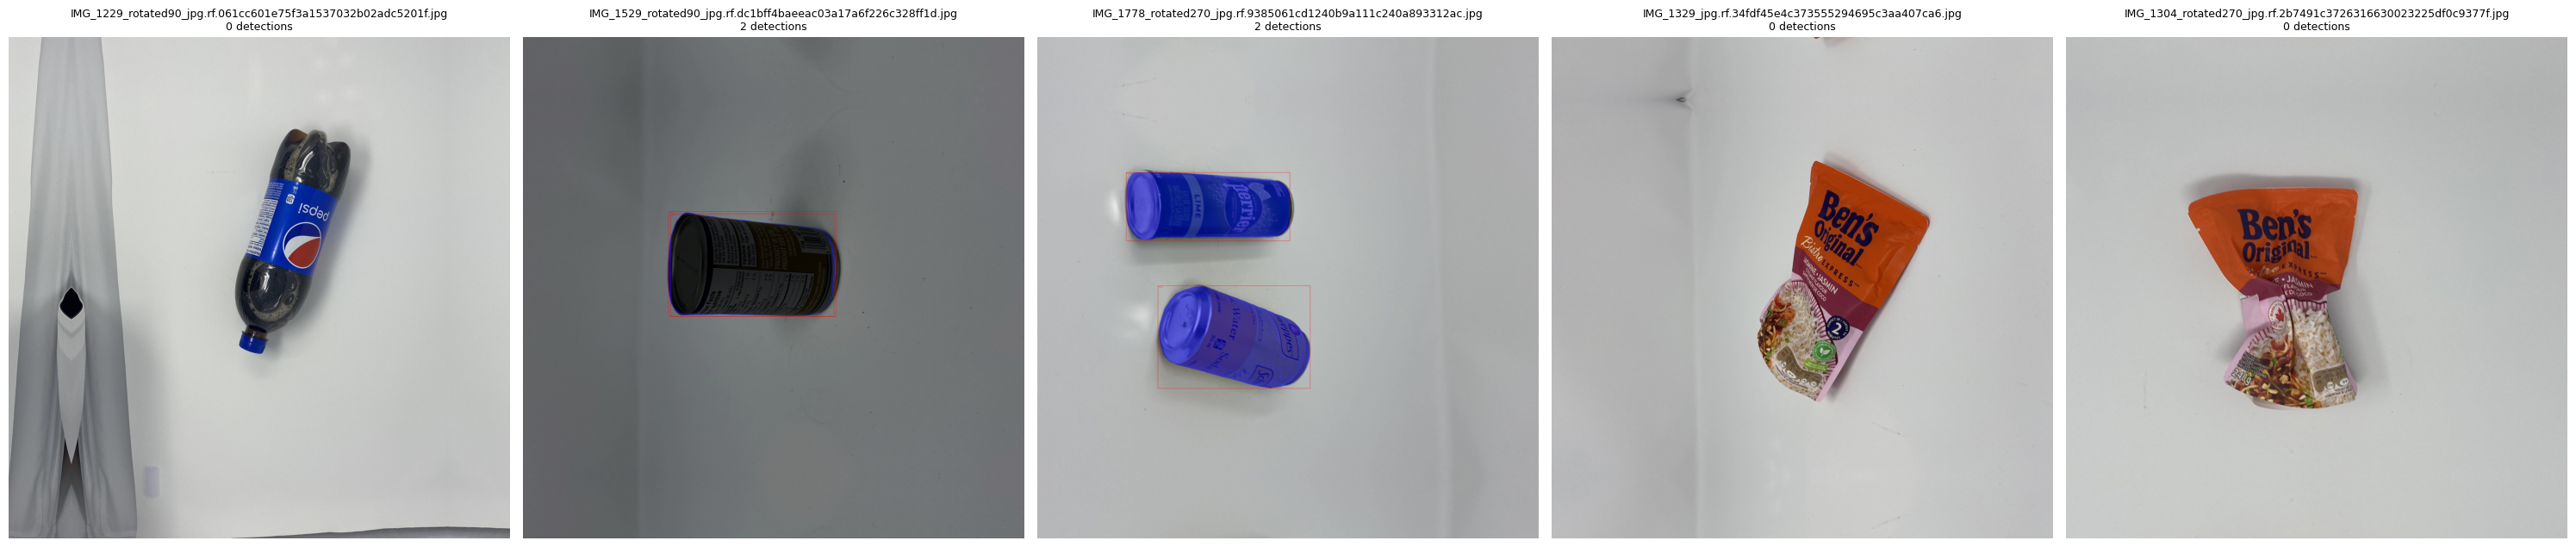

In [33]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
from torchvision.io import read_image
from torchvision.transforms import v2


VAL_IMG_DIR = "/content/R2P2-2/test"
SCORE_THRESHOLD = 0.5
NUM_IMAGES = 5

CLASS_NAMES = {1: "object"}

# Set model to evaluation mode
model.eval()

# Define the exact same transform we used for validation
eval_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

# Get list of test images from the directory
img_files = [f for f in os.listdir(VAL_IMG_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))][:NUM_IMAGES]

# Setup the plot
fig, axes = plt.subplots(1, len(img_files), figsize=(6 * len(img_files), 8))
if len(img_files) == 1:
    axes = [axes]

for ax, img_file in zip(axes, img_files):
    img_path = os.path.join(VAL_IMG_DIR, img_file)

    # read_image returns a uint8 tensor [C, H, W] in the 0-255 range
    # We keep this raw version for drawing the boxes/masks later!
    raw_image = read_image(img_path)[:3, ...]

    # Apply transforms to get the float32 0.0 - 1.0 tensor for the model
    x = eval_transform(raw_image).to(device)

    # Forward pass
    with torch.no_grad():
        predictions = model([x])
        pred = predictions[0]

    # Filter out weak predictions using your SCORE_THRESHOLD
    keep = pred["scores"] >= SCORE_THRESHOLD
    boxes  = pred["boxes"][keep]
    labels = pred["labels"][keep]
    scores = pred["scores"][keep]
    masks  = pred["masks"][keep]

    # Start with the raw image to draw on
    output_image = raw_image.clone()

    # Draw boxes if we found any
    if len(boxes) > 0:
        pred_labels = [f"{CLASS_NAMES.get(l.item(), str(l.item()))}: {s:.2f}" for l, s in zip(labels, scores)]
        output_image = draw_bounding_boxes(output_image, boxes, pred_labels, colors="red", width=2)

    # Draw masks if we found any
    if len(masks) > 0:
        # Binarize masks at 0.5 and remove the channel dimension
        masks_binary = (masks > 0.5).squeeze(1).to(torch.bool)
        output_image = draw_segmentation_masks(output_image, masks_binary, alpha=0.5, colors="blue")

    # Display the final image
    ax.imshow(output_image.permute(1, 2, 0)) # Permute from [C, H, W] to [H, W, C] for matplotlib
    ax.set_title(f"{img_file}\n{len(boxes)} detections", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("val_predictions.png", dpi=150)
plt.show()

<b>Observation</b>
- Based on the visualization of the prediction, we can see that Only image out of 5 are capable in detecting by our model. It only shows that our model is not capable enough to predict and detect the unseed dataset.

## Training References

From there, you can check out the [torchvision references](https://github.com/pytorch/vision/tree/main/references) where you'll find
the actual training scripts we use to train our models.

**Disclaimer** The code in our references is more complex than what you'll
need for your own use-cases: this is because we're supporting different
backends (PIL, tensors, TVTensors) and different transforms namespaces (v1 and
v2). So don't be afraid to simplify and only keep what you need.



# <font size = 6>YOLO TRAINING PART

In [1]:
# Welcom to another pretrained model that is capable of
# image segmentation and bounding boxes


# first we need to install ultralytics
!pip install ultralytics > /dev/null

In [2]:
# since we are using another model
# the yolo only accepts its own file formats
# So we need to download again

!pip install roboflow > /dev/null

from roboflow import Roboflow
rf = Roboflow(api_key="pGRthGiIPMMgCIST4ApK")
project = rf.workspace("new-workspace-crr3c").project("r2p2")
version = project.version(2)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to R2P2-2 in yolo26:: 100%|██████████| 5502/5502 [00:17<00:00, 317.71it/s] 


In [4]:
from ultralytics import YOLO

model = YOLO("yolo26n-seg.pt")

model.train(data="/content/R2P2-2/data.yaml", epochs=5)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/R2P2-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=Fa

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x787623fba240>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004

> As observed with the output metrics, the model achieved an average of .889 mAP50-95 which is performs significantly better than the previous model.


0: 640x640 1 rice, 15.5ms
1: 640x640 1 jam, 15.5ms
2: 640x640 2 jams, 15.5ms
3: 640x640 1 jam, 15.5ms
4: 640x640 2 jams, 15.5ms
Speed: 4.1ms preprocess, 15.5ms inference, 6.3ms postprocess per image at shape (1, 3, 640, 640)


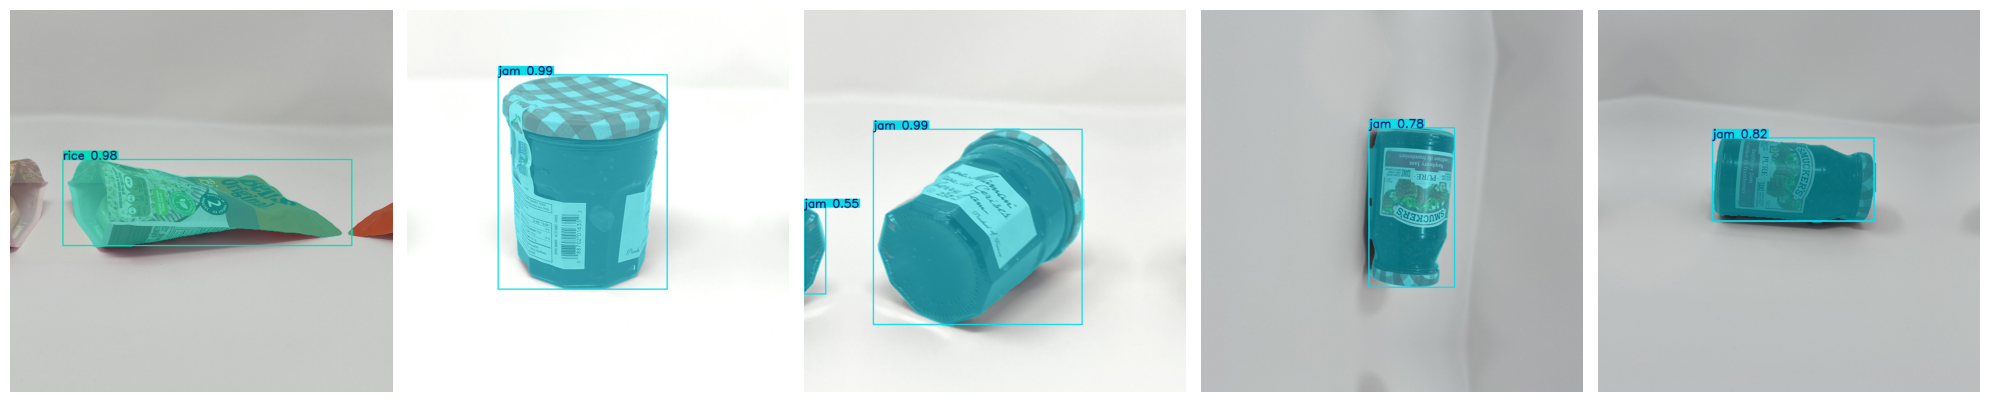

In [5]:
import matplotlib.pyplot as plt
import glob
import os


image_dir = "/content/R2P2-2/valid/images/"

image_paths = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))[5:10]


preds = model.predict(source=image_paths)


fig, axes = plt.subplots(1, 5, figsize=(20, 5))


for i, pred in enumerate(preds):
    res_plotted = pred.plot()
    res_rgb = res_plotted[:, :, ::-1]

    axes[i].imshow(res_rgb)
    axes[i].axis('off')


plt.tight_layout()
plt.show()

> Based on the images shown, three bounding boxes have a confidence level of 0.98 and above meaning that it can differentiate items in the unseen dataset. Additionally, all of the bounding boxes are correctly classified, even the small portion of object in the middle image.

## Conclusion

**Anduque**
> After completing the activity we were able learn how to use to pretrained model such fast_rcnn using pytorch for object detection and segmenetation task. While doing the activity, we assigned to use our own dataset for a given which is the mask R-CNN with resnet 50 for segmentation and object detection. In the train part of this model, we are able to discover that even if the model is able to obtain minimal loss for training set, it still perform poorly in the unseen dataset which indicates that the model is severly overfits. Because of this, our team try to use another model that is capable of performing the same using YOLOV11-seg.pt. Based on the result of the training and validation, it performs very well. Furthermore, it shows a good result in the metrics as well as the visualization of its prediction. Overall, the activity is very intersting because we discover different models that can be use for object detection and instance segmentation which can be apply for the future projects.

**Lim**
> A

**Rodriguez**
> In this activity we were able to demonstrate how we can train a pytorch model for object detection and segmnentation. In this activity, the model was for segmentation using mask R-CNN with resnet50. The important lesson I learned here was that for object detection with COCO, annonations are important. They are basically another set of dataset that accompanies the images and they hold the information for the bounding boxes and masks for segmentation.